# Pseudo-Labeling Emosi Twitter Indonesia

Pipeline semi-supervised learning menggunakan GRU untuk klasifikasi emosi tweet berbahasa Indonesia. Model dilatih pada data berlabel, kemudian digunakan untuk memberikan pseudo-label pada data tidak berlabel dengan threshold confidence.

## 1. Environment Setup

In [3]:
import os
import re
import copy
import random
import unicodedata
from collections import Counter

import emoji
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix


### 1.1 Import Library

Mengimpor seluruh dependensi yang dibutuhkan sepanjang pipeline: pemrosesan data, deep learning, dan evaluasi. Library `emoji` ditambahkan untuk konversi emoji ke token teks sebelum normalisasi encoding.

### 1.2 Konfigurasi Global

Menetapkan semua hyperparameter, path file, dan random seed di satu tempat agar mudah dimodifikasi.

In [4]:
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Path dataset
DATA_PATH           = '/kaggle/input/datasets/raditya0/twitter-emotion-dataset/Twitter_Emotion_Dataset.csv'
KAMUS_PATH          = '/kaggle/input/datasets/raditya0/twitter-emotion-dataset/kamus_singkatan.csv'
UNLABELED_DATA_PATH = '/kaggle/input/datasets/mrmfrhann234/scraping-xtwitter/Scraping_X_normalized.csv'
MODEL_PATH          = '/kaggle/input/models/raditya0/indonesian-twitter-emotion-model/pytorch/default/1/best_GRU.pt'
OUTPUT_PATH         = 'dataset_tambahan_pseudo_labeled.csv'

# Vocabulary & tokenisasi
MIN_FREQ  = 2
MAX_VOCAB = 20000
MAX_LEN   = 60   # dinaikkan dari 50 agar tweet panjang tidak terpotong
PAD_TOKEN = '<PAD>'
UNK_TOKEN = '<UNK>'

# Arsitektur model
EMBED_DIM  = 128
HIDDEN_DIM = 128
NUM_LAYERS = 2
DROPOUT    = 0.3

# Training
BATCH_SIZE    = 64
LEARNING_RATE = 0.001
EPOCHS_INIT   = 10

# Pseudo-labeling
# Threshold diturunkan dari 0.65 -> 0.55 karena data unlabeled domain-spesifik
# (tweet politik lokal) sehingga model cenderung underconfident pada data OOV.
# Dengan ~6100 data, target ~4500 label berarti perlu coverage ~74%,
# threshold 0.55 memberi ruang lebih sambil tetap memfilter prediksi acak.
CONFIDENCE_THRESHOLD  = 0.55
MAX_PSEUDO_ITERATIONS = 15
SAMPLE_RATE           = 0.3
EPOCHS_PER_ITER       = 5
PATIENCE              = 3


## 2. Dataset Load

### 2.1 Load Data Berlabel

Membaca dataset emosi berlabel dan menormalkan nama kolom. Kolom teks dipastikan bernama `tweet` dan kolom target bernama `label`.

In [5]:
df_labeled = pd.read_csv(DATA_PATH)
df_labeled.columns = [c.lower().strip() for c in df_labeled.columns]

# Pastikan kolom teks bernama 'tweet'
if 'tweet' not in df_labeled.columns:
    text_candidates = [c for c in df_labeled.columns if c not in ['label']]
    if text_candidates:
        df_labeled.rename(columns={text_candidates[0]: 'tweet'}, inplace=True)

df_labeled = df_labeled[['tweet', 'label']].dropna().reset_index(drop=True)

df_labeled.head(3)

,tweet,label
0,"Soal jln Jatibaru,polisi tdk bs GERTAK gubernu...",anger
1,"Sesama cewe lho (kayaknya), harusnya bisa lebi...",anger
2,Kepingin gudeg mbarek Bu hj. Amad Foto dari go...,happy


### 2.2 Load Data Tidak Berlabel 

In [6]:
def load_scraping_x_csv(path):
    """
    Membaca CSV hasil scraping Twitter yang setiap barisnya dibungkus
    tanda kutip luar (format anomali export Google Sheets / scraper tertentu).
    Jika format normal, fallback ke pd.read_csv biasa.
    """
    import io
    with open(path, 'r', encoding='utf-8') as f:
        raw = f.read()

    lines = raw.strip().split('\n')
    # Deteksi anomali: baris pertama diawali dan diakhiri tanda kutip
    first = lines[0].strip()
    if first.startswith('"') and first.endswith('"'):
        cleaned = '\n'.join(line.strip('"') for line in lines)
        return pd.read_csv(io.StringIO(cleaned))
    return pd.read_csv(path)


df_unlabeled = load_scraping_x_csv(UNLABELED_DATA_PATH)
df_unlabeled.columns = [c.lower().strip() for c in df_unlabeled.columns]

# Prioritas deteksi kolom teks: full_text > text > tweet > fallback
TEXT_COL_PRIORITY = ['full_text', 'text', 'tweet']
detected_col = None
for col in TEXT_COL_PRIORITY:
    if col in df_unlabeled.columns:
        detected_col = col
        break

if detected_col is None:
    non_id_cols = [c for c in df_unlabeled.columns
                   if not any(kw in c for kw in ['id', 'count', 'url', 'at', 'lang'])]
    detected_col = non_id_cols[0] if non_id_cols else df_unlabeled.columns[0]

if detected_col != 'tweet':
    df_unlabeled.rename(columns={detected_col: 'tweet'}, inplace=True)

df_unlabeled = df_unlabeled[['tweet']].dropna().reset_index(drop=True)

df_unlabeled.head(3)


,tweet
0,@USER Jangan takut kompetisi jangan takut komp...
1,BAHLIL ANJ
2,@USER Ya ga paham adiknya Bahlil berarti


### 2.3 Load Kamus Singkatan


In [7]:
try:
    kamus_df = pd.read_csv(KAMUS_PATH)
    KAMUS = dict(zip(
        kamus_df.iloc[:, 0].str.lower(),
        kamus_df.iloc[:, 1].str.lower()
    ))
except Exception:
    KAMUS = {}

## 3. Praproses Teks

### 3.1 Definisi Fungsi Pembersihan

Teks tweet dibersihkan melalui pipeline berurutan berikut:

1. **Konversi emoji** ke token teks (`<emoji_joy>`, `<emoji_sob>`, dst.) sebelum normalisasi encoding, agar sinyal emosi dari emoji tidak ikut terbuang.
2. **Pembersihan unicode noise** — karakter zero-width joiner dan non-breaking space dihapus, tapi tanpa encode ke ASCII sehingga karakter Latin dari bahasa Indonesia tetap utuh.
3. **Penggantian entitas Twitter** — URL, mention, dan hashtag diganti token khusus.
4. **Angka jadi token** `<angka>` — bukan dihapus, karena angka kadang bermakna ("lulus tahun 2024" vs "utang 0").
5. **Token ekspresi tipografis** — tanda seru/tanya berulang dan huruf kapital panjang.
6. **Normalisasi singkatan** via kamus (jika tersedia).
7. **Normalisasi elongated** — karakter berulang lebih dari 2x dipotong jadi 2 (bukan 1) agar bentuk `sakitt` masih bisa dikenali kamus singkatan atau dicocokkan dengan `sakit` melalui vocabulary overlap.
8. **Lowercase dan pembersihan tanda baca** — mempertahankan token `<...>` dan `<..._...>`.

In [8]:
def normalize_dict_words(text, dictionary):
    """Mengganti kata informal dengan bentuk bakunya menggunakan kamus."""
    if not dictionary:
        return text
    words = text.split()
    return ' '.join(dictionary.get(w, w) for w in words)


def clean_tweet(text, kamus=None):
    """Pipeline pembersihan satu teks tweet. Mengembalikan list token."""
    if not isinstance(text, str):
        return []

    # 1. Konversi emoji ke token teks sebelum encoding agar sinyal emosi tidak hilang
    text = emoji.demojize(text, language='alias')
    text = re.sub(r':([a-z][a-z0-9_]*):', r' <emoji_\1> ', text)

    # 2. Hapus unicode noise (zero-width, non-breaking space) tanpa strip ke ASCII
    text = re.sub(r'[\u200b-\u200f\u202a-\u202e\ufe0f\xa0]', ' ', text)
    text = unicodedata.normalize('NFKC', text)

    # 3. Ganti entitas Twitter dengan token khusus
    text = re.sub(r'http\S+|www\S+|https\S+', ' <url> ', text)
    text = re.sub(r'@\w+', ' <user> ', text)
    text = re.sub(r'#(\w+)', r' <hashtag> \1 ', text)

    # 4. Angka jadi token (tidak dihapus) agar konteks numerik tetap terwakili
    text = re.sub(r'\d+', ' <angka> ', text)

    # 5. Token ekspresi tipografis
    text = re.sub(r'!{2,}', ' <multiexclamation> ', text)
    text = re.sub(r'\?{2,}', ' <multiquestion> ', text)
    text = re.sub(r'\.{2,}', ' <multistop> ', text)
    text = re.sub(r'\b[A-Z]{3,}\b', lambda m: m.group() + ' <allcaps> ', text)

    text = text.lower()

    # 6. Normalisasi singkatan via kamus
    if kamus:
        text = normalize_dict_words(text, kamus)

    # 7. Normalisasi elongated: potong ke 2 karakter (bukan 1) agar 'sakitt' ~ 'sakit'
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)

    # 8. Hapus tanda baca, pertahankan token <...> dan <..._...>
    text = re.sub(r'[^\w\s<>]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    tokens = [t for t in text.split() if len(t) > 1]
    return tokens


### 3.2 Aplikasi Pembersihan ke Dataset

Menerapkan `clean_tweet` pada seluruh baris data berlabel dan tidak berlabel.

In [9]:
df_labeled['tokens']   = df_labeled['tweet'].apply(lambda x: clean_tweet(x, kamus=KAMUS))
df_unlabeled['tokens'] = df_unlabeled['tweet'].apply(lambda x: clean_tweet(x, kamus=KAMUS))

## 4. Pembangunan Vocabulary dan Encoding

### 4.1 Bangun Vocabulary dari Data Berlabel

Vocabulary dibangun hanya dari data berlabel untuk menghindari kebocoran informasi dari data unlabeled. Kata dengan frekuensi di bawah `MIN_FREQ` dibuang.

In [10]:
all_tokens = [tok for tokens in df_labeled['tokens'] for tok in tokens]
freq = Counter(all_tokens)
vocab_words = [w for w, c in freq.most_common(MAX_VOCAB) if c >= MIN_FREQ]

word2idx = {PAD_TOKEN: 0, UNK_TOKEN: 1}
word2idx.update({w: i + 2 for i, w in enumerate(vocab_words)})
idx2word = {v: k for k, v in word2idx.items()}
VOCAB_SIZE = len(word2idx)

### 3.3 Diagnostik Preprocessing

Menghitung UNK rate dan statistik token untuk memverifikasi bahwa preprocessing tidak membuang terlalu banyak informasi. UNK rate > 0.5 per tweet mengindikasikan vocabulary gap yang serius antara data berlabel dan tidak berlabel.

In [ ]:
# Estimasi UNK rate pada data unlabeled menggunakan vocabulary dari data berlabel
def compute_unk_rate(tokens_series, word2idx, max_len):
    rates = []
    for tokens in tokens_series:
        ids = tokens[:max_len]
        if not ids:
            rates.append(1.0)
            continue
        unk_count = sum(1 for t in ids if word2idx.get(t, 1) == 1)
        rates.append(unk_count / len(ids))
    return rates


unk_rates = compute_unk_rate(df_unlabeled['tokens'], word2idx, MAX_LEN)
unk_series = pd.Series(unk_rates)

print('UNK Rate per tweet pada data unlabeled:')
print(unk_series.describe().round(3))
print()
print(f'Tweet dengan UNK rate > 0.5 : {(unk_series > 0.5).sum()} ({(unk_series > 0.5).mean()*100:.1f}%)')
print(f'Tweet dengan UNK rate > 0.75: {(unk_series > 0.75).sum()} ({(unk_series > 0.75).mean()*100:.1f}%)')
print()
print('Distribusi panjang token (unlabeled):')
token_lens = df_unlabeled['tokens'].apply(len)
print(token_lens.describe().round(1))


### 4.2 Encode Token ke Indeks Integer

Setiap sequence token dikonversi ke list indeks integer, dipotong di `MAX_LEN`, dan dipadding dengan 0 jika kurang.

In [11]:
def encode_tokens(tokens, word2idx, max_len):
    ids = [word2idx.get(t, 1) for t in tokens[:max_len]]
    ids += [0] * (max_len - len(ids))
    return ids


df_labeled['encoded']   = df_labeled['tokens'].apply(lambda t: encode_tokens(t, word2idx, MAX_LEN))
df_unlabeled['encoded'] = df_unlabeled['tokens'].apply(lambda t: encode_tokens(t, word2idx, MAX_LEN))

### 4.3 Encode Label Kelas

Label string dikonversi ke indeks integer menggunakan `LabelEncoder`. Daftar kelas disimpan untuk digunakan saat decoding prediksi.

In [12]:
le = LabelEncoder()
df_labeled['label_encoded'] = le.fit_transform(df_labeled['label'])
CLASSES     = le.classes_.tolist()
NUM_CLASSES = len(CLASSES)

## 5. Dataset dan DataLoader PyTorch

### 5.1 Definisi Class TweetDataset

`TweetDataset` membungkus encoded sequence dan label (opsional) ke format yang kompatibel dengan `DataLoader`. Jika `labels=None`, dataset berfungsi untuk inference saja.

In [13]:
class TweetDataset(Dataset):
    def __init__(self, encodings, labels=None):
        self.X = torch.tensor(encodings, dtype=torch.long)
        self.y = torch.tensor(labels, dtype=torch.long) if labels is not None else None

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        if self.y is not None:
            return self.X[idx], self.y[idx]
        return self.X[idx]

### 5.2 Split Data dan Buat DataLoader

Data berlabel dibagi dengan rasio 70/15/15 (train/val/test) secara stratified. DataLoader dibuat untuk masing-masing split dan untuk data unlabeled.

In [14]:
X_all = df_labeled['encoded'].tolist()
y_all = df_labeled['label_encoded'].tolist()

X_train, X_temp, y_train, y_temp = train_test_split(
    X_all, y_all, test_size=0.30, random_state=SEED, stratify=y_all
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

train_loader    = DataLoader(TweetDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader      = DataLoader(TweetDataset(X_val,   y_val),   batch_size=BATCH_SIZE)
test_loader     = DataLoader(TweetDataset(X_test,  y_test),  batch_size=BATCH_SIZE)

X_unlabeled     = df_unlabeled['encoded'].tolist()
unlabeled_loader = DataLoader(TweetDataset(X_unlabeled), batch_size=BATCH_SIZE, shuffle=False)

## 6. Arsitektur Model GRU

### 6.1 Definisi GRUClassifier

Model terdiri dari Embedding layer, Bidirectional GRU dua lapis, dan Linear classifier. Hidden state terakhir dari kedua arah digabungkan sebelum masuk ke fully connected layer.

In [15]:
class GRUClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes,
                 num_layers=2, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.gru = nn.GRU(
            embed_dim, hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=True
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        x = self.dropout(self.embedding(x))
        _, h = self.gru(x)
        # Ambil hidden state layer terakhir dari kedua arah
        h = torch.cat((h[-2], h[-1]), dim=1)
        return self.fc(self.dropout(h))

### 6.2 Definisi Focal Loss

Focal Loss adalah modifikasi dari Cross-Entropy yang menambahkan faktor `(1 - p_t)^gamma` pada setiap sampel. Sampel yang mudah diprediksi (confidence tinggi) mendapat bobot kecil, sedangkan sampel sulit (kelas minoritas atau ambigu) mendapat bobot lebih besar. Ini mengatasi ketidakimbangan kelas tanpa harus melakukan oversampling.

Parameter `alpha` mengontrol bobot per kelas (dihitung otomatis dari frekuensi label di data train), dan `gamma` mengontrol seberapa tajam penalti diberikan ke sampel mudah — nilai default `gamma=2` umumnya efektif untuk kasus NLP.

In [16]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        """
        alpha : tensor bobot per kelas (opsional), shape [num_classes]
        gamma : focusing parameter — semakin besar semakin fokus ke sampel sulit
        """
        super().__init__()
        self.alpha     = alpha
        self.gamma     = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        # Cross-entropy per sampel (tanpa reduksi)
        ce_loss = nn.functional.cross_entropy(logits, targets, reduction='none')

        # p_t: probabilitas kelas yang benar
        p_t = torch.exp(-ce_loss)

        # Focal weight
        focal_weight = (1 - p_t) ** self.gamma

        # Terapkan alpha per kelas jika tersedia
        if self.alpha is not None:
            alpha_t = self.alpha.to(logits.device)[targets]
            focal_weight = alpha_t * focal_weight

        loss = focal_weight * ce_loss

        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        return loss


In [17]:
model = GRUClassifier(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    num_classes=NUM_CLASSES,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
).to(DEVICE)

# Hitung alpha per kelas dari frekuensi label di data train
# Kelas minoritas mendapat bobot lebih besar secara proporsional
label_counts_train = Counter(y_train)
total_train        = len(y_train)
alpha_weights = torch.tensor(
    [total_train / (NUM_CLASSES * label_counts_train.get(i, 1)) for i in range(NUM_CLASSES)],
    dtype=torch.float
)

criterion = FocalLoss(alpha=alpha_weights, gamma=2.0)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)


## 7. Training Awal pada Data Berlabel

### 7.1 Fungsi Evaluasi

Menghitung akurasi model pada DataLoader yang diberikan tanpa menghitung gradient.

In [18]:
def evaluate_model(model, loader):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            outputs = model(X_batch)
            _, predicted = torch.max(outputs, 1)
            total   += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()
    return correct / total

### 7.2 Loop Training Awal

Model dilatih pada data berlabel selama `EPOCHS_INIT` epoch dengan early stopping berdasarkan akurasi validasi. Bobot terbaik disimpan untuk digunakan pada tahap pseudo-labeling.

In [19]:
best_val_acc      = 0.0
best_model_state  = copy.deepcopy(model.state_dict())
init_loss_history = []
init_acc_history  = []

for epoch in range(1, EPOCHS_INIT + 1):
    model.train()
    epoch_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    val_acc  = evaluate_model(model, val_loader)

    init_loss_history.append(avg_loss)
    init_acc_history.append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc     = val_acc
        best_model_state = copy.deepcopy(model.state_dict())

model.load_state_dict(best_model_state)

<All keys matched successfully>

## 8. Pseudo-Labeling Semi-Supervised

### 8.1 Loop Pseudo-Labeling Iteratif

Pada setiap iterasi, model memprediksi label untuk data unlabeled. Prediksi dengan confidence (softmax probability) di atas threshold digabungkan dengan data train asli, kemudian model dilatih ulang. Iterasi berhenti jika akurasi validasi tidak meningkat selama `PATIENCE` iterasi berturut-turut.

In [20]:
from collections import defaultdict

def balanced_sampling(pseudo_x, pseudo_y, max_per_class=None):
    class_dict = defaultdict(list)
    
    for x, y in zip(pseudo_x, pseudo_y):
        class_dict[y].append(x)
    
    # Cari jumlah minimum per class
    min_count = min(len(v) for v in class_dict.values())
    
    if max_per_class:
        min_count = min(min_count, max_per_class)
    
    balanced_x, balanced_y = [], []
    
    for cls, items in class_dict.items():
        sampled = items[:min_count]
        balanced_x.extend(sampled)
        balanced_y.extend([cls] * len(sampled))
    
    return balanced_x, balanced_y

In [21]:
pseudo_val_acc_history   = [best_val_acc]
pseudo_train_loss_history = []
pseudo_samples_count     = []

bad_epochs        = 0
best_pseudo_acc   = best_val_acc
best_pseudo_state = copy.deepcopy(model.state_dict())

for iteration in range(MAX_PSEUDO_ITERATIONS):

    # --- Tahap 1: Hasilkan pseudo-label dari data unlabeled ---
    model.eval()
    pseudo_x, pseudo_y = [], []

    with torch.no_grad():
        for batch in unlabeled_loader:
            inputs  = batch.to(DEVICE)
            outputs = model(inputs)
            probs   = torch.softmax(outputs, dim=1)
            max_probs, preds = torch.max(probs, dim=1)

            # Filter berdasarkan confidence threshold
            mask = max_probs >= CONFIDENCE_THRESHOLD
            pseudo_x.extend(inputs[mask].cpu().tolist())
            pseudo_y.extend(preds[mask].cpu().tolist())

    if len(pseudo_x) == 0:
        break

    # --- Tahap 2: Class-balanced sampling ---
    balanced_x, balanced_y = balanced_sampling(pseudo_x, pseudo_y)
    
    # Optional: sampling tambahan jika masih terlalu banyak
    combined = list(zip(balanced_x, balanced_y))
    random.shuffle(combined)
    
    num_samples = int(len(combined) * SAMPLE_RATE)
    sampled = combined[:num_samples]
    

    if len(sampled) == 0:
        break

    sampled_x, sampled_y = zip(*sampled)
    pseudo_samples_count.append(len(sampled_x))

    # --- Tahap 3: Gabungkan dan latih ---
    X_combined = X_train + list(sampled_x)
    y_combined = y_train + list(sampled_y)

    combined_loader = DataLoader(
        TweetDataset(X_combined, y_combined),
        batch_size=BATCH_SIZE,
        shuffle=True
    )

    model.train()
    iter_loss = 0.0

    for _ in range(EPOCHS_PER_ITER):
        epoch_loss = 0.0
        for X_batch, y_batch in combined_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss    = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        iter_loss += epoch_loss / len(combined_loader)

    pseudo_train_loss_history.append(iter_loss / EPOCHS_PER_ITER)

    # --- Tahap 4: Evaluasi dan early stopping ---
    current_val_acc = evaluate_model(model, val_loader)
    pseudo_val_acc_history.append(current_val_acc)

    if current_val_acc > best_pseudo_acc:
        best_pseudo_acc   = current_val_acc
        best_pseudo_state = copy.deepcopy(model.state_dict())
        bad_epochs = 0
    else:
        bad_epochs += 1

    if bad_epochs >= PATIENCE:
        break

model.load_state_dict(best_pseudo_state)

<All keys matched successfully>

### 8.2 Ekspor Dataset Pseudo-Label Final

Model terbaik hasil pseudo-labeling digunakan sekali lagi untuk memprediksi seluruh data unlabeled. Hanya prediksi dengan confidence di atas threshold yang disimpan ke file CSV output.

In [22]:
model.eval()
final_pseudo_texts  = []
final_pseudo_labels = []
texts_unlabeled     = df_unlabeled['tweet'].tolist()

with torch.no_grad():
    for i, batch in enumerate(unlabeled_loader):
        inputs  = batch.to(DEVICE)
        outputs = model(inputs)
        probs   = torch.softmax(outputs, dim=1)
        max_probs, preds = torch.max(probs, dim=1)

        start_idx = i * BATCH_SIZE
        for j, (prob, pred) in enumerate(zip(max_probs.cpu(), preds.cpu())):
            if prob.item() >= CONFIDENCE_THRESHOLD:
                original_idx = start_idx + j
                if original_idx < len(texts_unlabeled):
                    final_pseudo_texts.append(texts_unlabeled[original_idx])
                    final_pseudo_labels.append(CLASSES[pred.item()])

df_pseudo_final = pd.DataFrame({
    'tweet': final_pseudo_texts,
    'label': final_pseudo_labels
})

df_pseudo_final.to_csv(OUTPUT_PATH, index=False)

## 9. Evaluasi Akhir

### 9.1 Classification Report dan Confusion Matrix

Mengevaluasi performa model akhir pada test set yang belum pernah dilihat selama training maupun pseudo-labeling.

In [23]:
model.eval()
all_preds   = []
all_targets = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        outputs = model(X_batch)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(y_batch.numpy())

print(classification_report(all_targets, all_preds, target_names=CLASSES))

              precision    recall  f1-score   support

       anger       0.60      0.63      0.62       166
        fear       0.64      0.69      0.66        97
       happy       0.62      0.48      0.54       153
        love       0.73      0.78      0.76        95
     sadness       0.44      0.47      0.46       150

    accuracy                           0.59       661
   macro avg       0.61      0.61      0.61       661
weighted avg       0.59      0.59      0.59       661



### 9.2 Confusion Matrix

Visualisasi confusion matrix untuk melihat distribusi kesalahan prediksi antar kelas emosi.

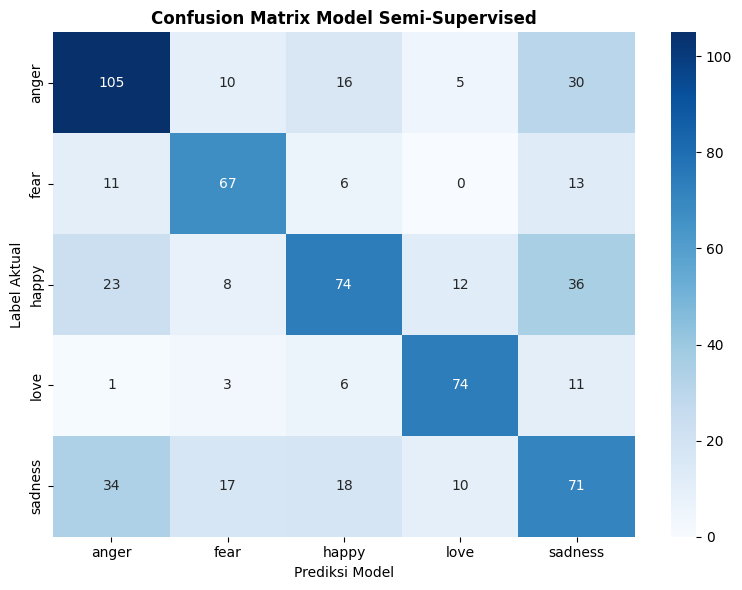

In [24]:
cm = confusion_matrix(all_targets, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('Confusion Matrix Model Semi-Supervised', fontweight='bold')
plt.xlabel('Prediksi Model')
plt.ylabel('Label Aktual')
plt.tight_layout()
plt.show()

## 10. Visualisasi Proses Training

### 10.1 Kurva Loss dan Akurasi Training Awal

Menampilkan perubahan loss training dan akurasi validasi per epoch pada fase training supervised awal.

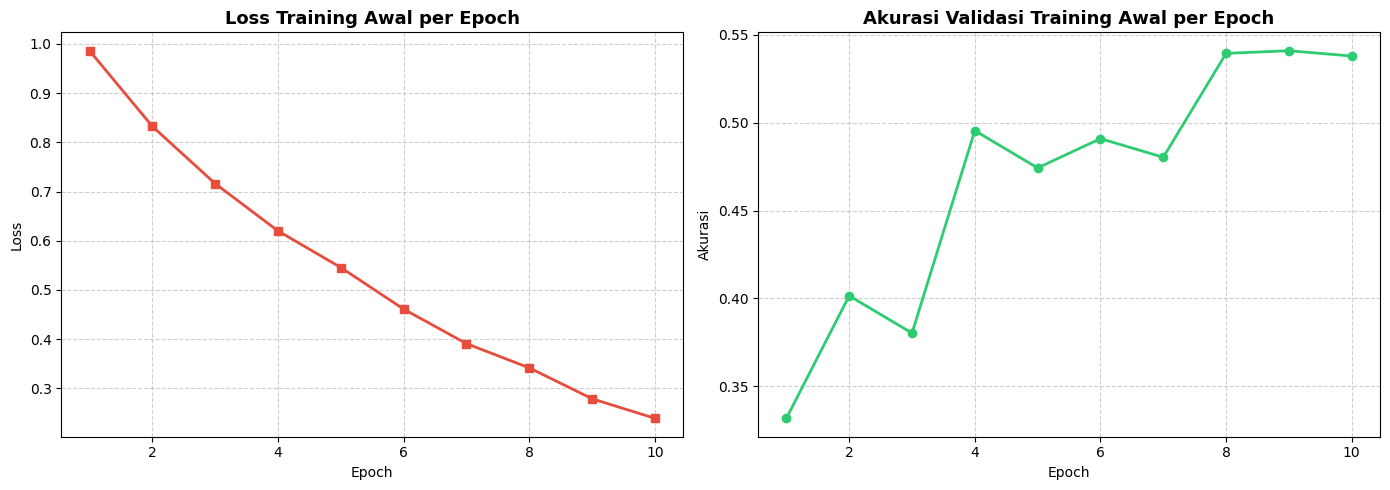

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, len(init_loss_history) + 1), init_loss_history,
             marker='s', color='#e74c3c', linewidth=2)
axes[0].set_title('Loss Training Awal per Epoch', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True, linestyle='--', alpha=0.6)

axes[1].plot(range(1, len(init_acc_history) + 1), init_acc_history,
             marker='o', color='#2ecc71', linewidth=2)
axes[1].set_title('Akurasi Validasi Training Awal per Epoch', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Akurasi')
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### 10.2 Kurva Loss dan Akurasi Pseudo-Labeling

Menampilkan perubahan loss training dan akurasi validasi per iterasi pseudo-labeling, termasuk jumlah sampel pseudo-label yang digunakan setiap iterasi.

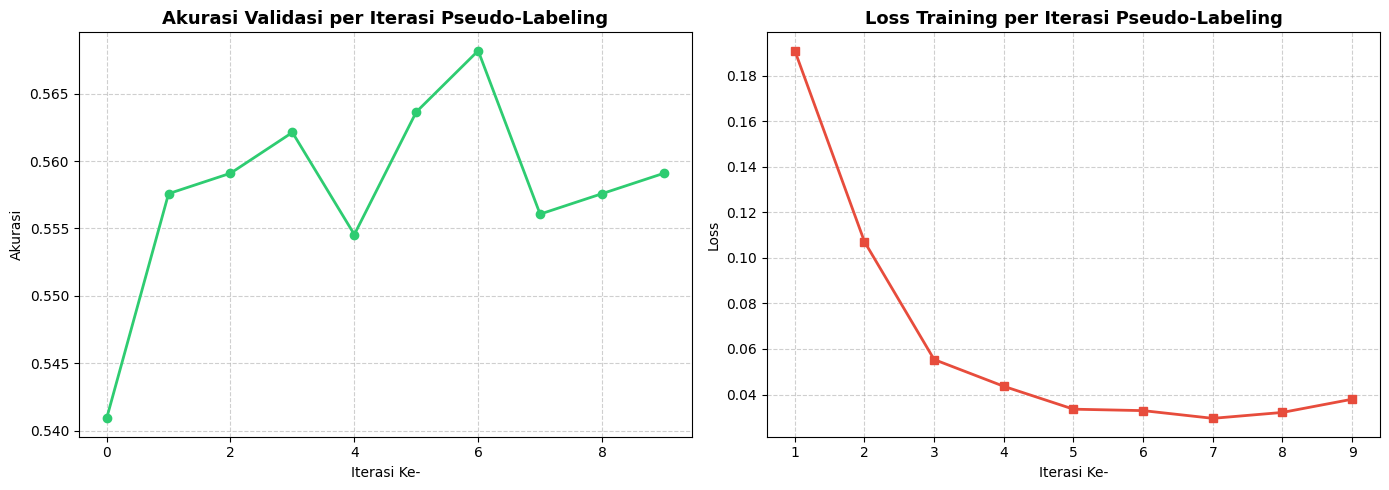

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(len(pseudo_val_acc_history)), pseudo_val_acc_history,
             marker='o', color='#2ecc71', linewidth=2)
axes[0].set_title('Akurasi Validasi per Iterasi Pseudo-Labeling', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Iterasi Ke-')
axes[0].set_ylabel('Akurasi')
axes[0].grid(True, linestyle='--', alpha=0.6)

axes[1].plot(range(1, len(pseudo_train_loss_history) + 1), pseudo_train_loss_history,
             marker='s', color='#e74c3c', linewidth=2)
axes[1].set_title('Loss Training per Iterasi Pseudo-Labeling', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Iterasi Ke-')
axes[1].set_ylabel('Loss')
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### 10.3 Distribusi Kelas Emosi pada Dataset Pseudo-Label

Bar chart menampilkan jumlah tweet per kelas emosi yang berhasil mendapat pseudo-label dengan confidence di atas threshold.

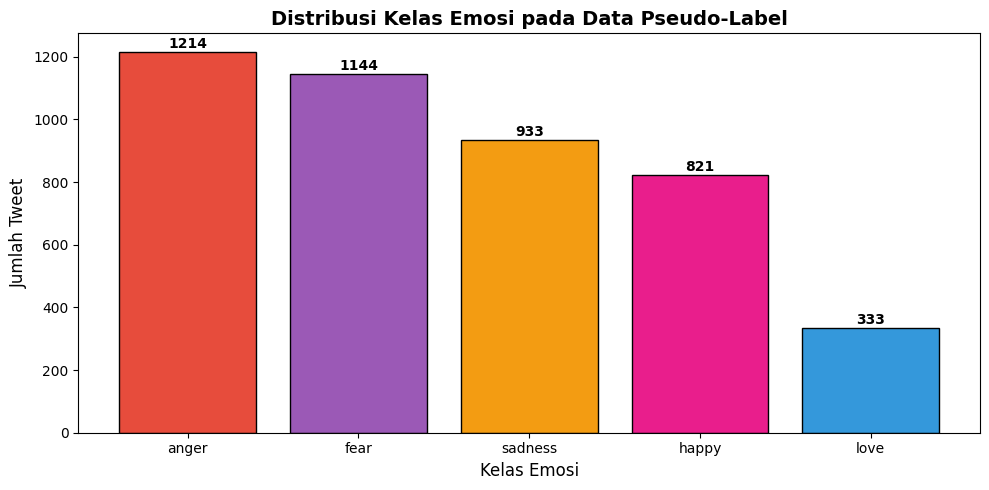

In [27]:
label_counts = df_pseudo_final['label'].value_counts()
colors = ['#e74c3c', '#9b59b6', '#f39c12', '#e91e8c', '#3498db',
          '#1abc9c', '#e67e22', '#2c3e50']

plt.figure(figsize=(10, 5))
bars = plt.bar(
    label_counts.index,
    label_counts.values,
    color=colors[:len(label_counts)],
    edgecolor='black'
)

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        yval + 5,
        str(int(yval)),
        ha='center', va='bottom', fontweight='bold'
    )

plt.title('Distribusi Kelas Emosi pada Data Pseudo-Label', fontsize=14, fontweight='bold')
plt.xlabel('Kelas Emosi', fontsize=12)
plt.ylabel('Jumlah Tweet', fontsize=12)
plt.tight_layout()
plt.show()

## 11. Verifikasi Hasil Pseudo-Label

Menampilkan sampel tweet dari data tidak berlabel beserta label emosi yang diberikan model dan nilai confidence-nya, sebagai bukti bahwa proses pseudo-labeling berjalan dengan benar.

In [28]:
model.eval()
texts_unlabeled = df_unlabeled['tweet'].tolist()
verify_texts, verify_labels, verify_confs = [], [], []

with torch.no_grad():
    for i, batch in enumerate(unlabeled_loader):
        inputs  = batch.to(DEVICE)
        outputs = model(inputs)
        probs   = torch.softmax(outputs, dim=1)
        max_probs, preds = torch.max(probs, dim=1)

        start_idx = i * BATCH_SIZE
        for j, (prob, pred) in enumerate(zip(max_probs.cpu(), preds.cpu())):
            original_idx = start_idx + j
            if original_idx < len(texts_unlabeled):
                verify_texts.append(texts_unlabeled[original_idx])
                verify_labels.append(CLASSES[pred.item()])
                verify_confs.append(round(prob.item(), 4))

df_verify = pd.DataFrame({
    'tweet'      : verify_texts,
    'pseudo_label': verify_labels,
    'confidence'  : verify_confs
})

# Tampilkan 5 sampel per kelas emosi yang berhasil di-pseudo-label
threshold_mask = df_verify['confidence'] >= CONFIDENCE_THRESHOLD
df_above = df_verify[threshold_mask].copy()

samples = (
    df_above
    .groupby('pseudo_label', group_keys=False)
    .apply(lambda x: x.nlargest(5, 'confidence'))
    .reset_index(drop=True)
)

pd.set_option('display.max_colwidth', 80)
samples

/tmp/ipykernel_55/919504448.py:33: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(5, 'confidence'))


,tweet,pseudo_label,confidence
0,@USER Kapan ada tragedi demo besar-besaran lagi? Para pemimpin di negeri kon...,anger,0.9996
1,the reason why gw ga percaya sm this religion ya krn kalimat pertama lu itu ...,anger,0.9993
2,orang yang hampir confess (bahkan udh confess tapi blm ngajak pacaran) trnya...,anger,0.9990
3,Itu kesimpulannya kalau menurut pengetahuan agama yang saya fahami. Berdasar...,anger,0.9990
4,selalu banyak masalah ga punya temen deket cuma kenal banyak orang ga pinter...,anger,0.9990
5,@USER @USER @USER @USER @USER @USER @USER @USER @USER @USER @USER @USER @USE...,fear,0.9995
6,@USER @USER Solo itu kota majemuk isinya macem-macem nggak cuma abangan dan ...,fear,0.9992
7,@USER @USER Samurai takut pada jawa,fear,0.9989
8,@USER @USER Jawa manaa aku juga jawa,fear,0.9988
9,@USER Waktu naik bis semarang banjir belum ada tol trans jawa putar lewat al...,fear,0.9987
